<a href="https://www.kaggle.com/code/sofiatanganho/2-0-modela-o-treino?scriptVersionId=309891940" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/fedesoriano/the-boston-houseprice-data/boston.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import kstest, norm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [3]:
df = pd.read_csv("/kaggle/input/datasets/fedesoriano/the-boston-houseprice-data/boston.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


# Código necessário do Milestone 2

In [4]:
# Variáveis
standard_vars = ['CRIM','RM','LSTAT','DIS','PTRATIO','B','ZN']  # standardização
normalize_vars = ['INDUS','NOX','AGE','RAD','TAX']              # normalização

# Padronização
scaler = StandardScaler()
df_standard = scaler.fit_transform(df[standard_vars])

# Criar novas colunas com sufixo _stand
for i, col in enumerate(standard_vars):
    df[f'{col}_stand'] = df_standard[:, i]

# Normalização
normalizer = MinMaxScaler()
df_normalized = normalizer.fit_transform(df[normalize_vars])

# Criar novas colunas com sufixo _norm
for i, col in enumerate(normalize_vars):
    df[f'{col}_norm'] = df_normalized[:, i]

# Verificar
print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  ...  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0  ...   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0  ...   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0  ...   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0  ...   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0  ...   

   LSTAT_stand  DIS_stand  PTRATIO_stand   B_stand  ZN_stand  INDUS_norm  \
0    -1.075562   0.140214      -1.459000  0.441052  0.284830    0.067815   
1    -0.492439   0.557160      -0.303094  0.441052 -0.487722    0.242302   
2    -1.208727   0.557160      -0.303094  0.396427 -0.487722    0.242302   
3    -1.361517   1.077737       0.113032  0.416163 -0.487722    0.063050   
4    -1.026501   1.077737       0.113032  0.441052 -0.487722    0.063050   

   NOX_norm  AGE_norm  RAD_norm  TAX_norm  
0  0.314815  0.641607  0.00000

In [5]:
 #Criação de Novos Atributos

# 1. Índice de Qualidade de Vida (IQV)
# Combina criminalidade, qualidade do ar e educação num só índice
df['IQV'] = (1 / df['CRIM']) + (1 / df['NOX']) + (1 / df['PTRATIO'])

# 2. Índice de Atratividade Habitacional (IAH)
# Relaciona o tamanho da habitação com a peso socioeconómico e a distancia a centros de emprego
df['IAH'] = df['RM'] / (df['LSTAT'] * df['DIS'])


# Verificar se foram criados corretamente
print(df[['IQV']].head())
print(df[['IQV']].describe())
print(df['IAH'].head())
print(df['IAH'].describe())

          IQV
0  160.151944
1   38.805000
2   38.831835
3   33.129684
4   16.719141
              IQV
count  506.000000
mean    11.679929
std     16.242551
min      1.446206
25%      1.883696
50%      5.739009
75%     14.532372
max    160.151944
0    0.322807
1    0.141434
2    0.358937
3    0.392642
4    0.221190
Name: IAH, dtype: float64
count    506.000000
mean       0.222874
std        0.214639
min        0.029853
25%        0.123168
50%        0.166978
75%        0.235522
max        2.196409
Name: IAH, dtype: float64


In [6]:
# Remover as variáveis originais e as respetivas escalonadas utilizadas na criação do IQV e do IAH e a variável RAD
df = df.drop(columns=['CRIM', 'NOX', 'PTRATIO', 'RM', 'LSTAT', 'DIS','RAD','CRIM_stand','NOX_norm','PTRATIO_stand','RM_stand','LSTAT_stand','DIS_stand','RAD_norm'])

# Verificar se foram removidas corretamente
print(df.columns)
print(df.shape)  

Index(['ZN', 'INDUS', 'CHAS', 'AGE', 'TAX', 'B', 'MEDV', 'B_stand', 'ZN_stand',
       'INDUS_norm', 'AGE_norm', 'TAX_norm', 'IQV', 'IAH'],
      dtype='object')
(506, 14)


In [7]:
# Adicionar as novas variáveis à lista de padronização
novas_vars = ['IQV', 'IAH']

# Padronização
df_standard_new = scaler.fit_transform(df[novas_vars])

# Criar novas colunas com sufixo _stand
for i, col in enumerate(novas_vars):
    df[f'{col}_stand'] = df_standard_new[:, i]

# Verificar
print(df[['IQV_stand', 'IAH_stand']].head())

   IQV_stand  IAH_stand
0   9.149976   0.466049
1   1.671653  -0.379803
2   1.673307   0.634547
3   1.321897   0.791729
4   0.310555  -0.007850


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ZN          506 non-null    float64
 1   INDUS       506 non-null    float64
 2   CHAS        506 non-null    int64  
 3   AGE         506 non-null    float64
 4   TAX         506 non-null    float64
 5   B           506 non-null    float64
 6   MEDV        506 non-null    float64
 7   B_stand     506 non-null    float64
 8   ZN_stand    506 non-null    float64
 9   INDUS_norm  506 non-null    float64
 10  AGE_norm    506 non-null    float64
 11  TAX_norm    506 non-null    float64
 12  IQV         506 non-null    float64
 13  IAH         506 non-null    float64
 14  IQV_stand   506 non-null    float64
 15  IAH_stand   506 non-null    float64
dtypes: float64(15), int64(1)
memory usage: 63.4 KB


# Milestone 3

In [9]:
# Separar variáveis preditoras (X) da variável alvo (y)
X = df.drop(columns=['MEDV'])
y = df['MEDV']

# Divisão 80% treino / 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treino: {X_train.shape}")
print(f"Teste: {X_test.shape}")

Treino: (404, 15)
Teste: (102, 15)


In [10]:
# 3. Treinar o Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

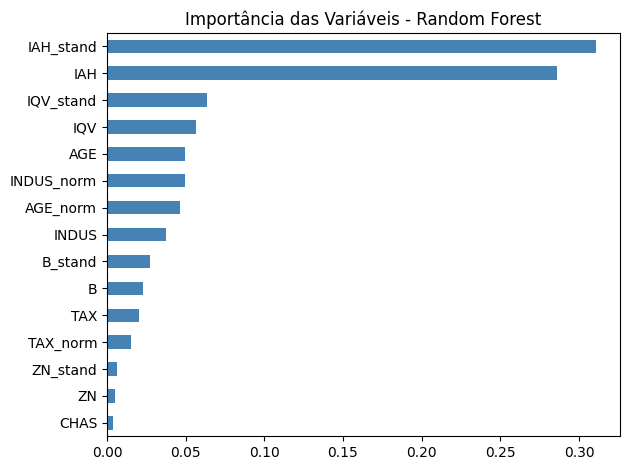

In [11]:
# Feature Importance do modelo vencedor

importancias = pd.Series(rf.feature_importances_, index=X.columns)
importancias.sort_values().plot(kind='barh', color='steelblue')
plt.title('Importância das Variáveis - Random Forest')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()